# **Full EDA on `hmda_2024_clean.parquet`**

This notebook finally performs the full exploratory data analysis that the README's Day 3 required but was deferred until the model pipeline was stable.

**Data source:** `data/processed/hmda_2024_clean.parquet` — the Day 2 output, **before** train/test split, **before** one-hot encoding, and **before** imputation. This is deliberate: the file still has real `NaN`s in `income`, `property_value`, `debt_to_income_ratio`, `loan_to_value_ratio`, `interest_rate`, which makes it the right file for genuine missingness EDA (modeling-stage files already impute these, which would hide the patterns EDA is supposed to surface).

**One column caveat:** `loan_to_income_ratio` was engineered in Day 4, so it does not exist in this file. It is recomputed inline as `loan_amount / income` (with income==0 guarded to NaN).

**Protocol:** all plots are rendered **inline** (`plt.show`) and **not** saved to a `figures/` directory — this is exploratory scratch work, not versioned deliverables. Summary statistics are computed on the **full** file; plots use a **250k reproducible sample** for speed.


In [1]:
import os, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

ROOT = Path('/Volumes/Mitul/Projects/home-mortage-approval-predictor')
DATA = ROOT / 'data' / 'processed'
FIG = ROOT / 'figures' / 'day9'
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA / 'hmda_2024_clean.parquet')
print('full file:', df.shape)

# Recompute loan_to_income_ratio inline (income==0 guarded to NaN)
df['loan_to_income_ratio'] = np.where(df['income'] > 0, df['loan_amount'] / df['income'], np.nan)

# Sample for plotting speed; stats computed on the full file
df_plot = df.sample(250000, random_state=42)
print('plot sample:', df_plot.shape)
print('approved share (full):', df['approved'].mean())

CONTINUOUS = ['loan_to_income_ratio', 'income', 'loan_amount', 'property_value', 'loan_to_value_ratio',
              'debt_to_income_ratio', 'interest_rate', 'rate_spread', 'loan_term',
              'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income',
              'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_one_to_four_family_homes',
              'tract_median_age_of_housing_units']
CATEGORICAL = ['loan_type', 'loan_purpose', 'lien_status', 'occupancy_type', 'construction_method',
               'derived_dwelling_category', 'applicant_credit_score_type', 'co_applicant_credit_score_type',
               'submission_of_application', 'reverse_mortgage', 'open_end_line_of_credit',
               'business_or_commercial_purpose', 'preapproval', 'negative_amortization', 'interest_only_payment',
               'balloon_payment', 'total_units']
PIE_LOW = ['loan_purpose', 'occupancy_type', 'preapproval', 'lien_status', 'derived_dwelling_category']
print('continuous:', len(CONTINUOUS), '| categorical:', len(CATEGORICAL), '| pie-low:', len(PIE_LOW))


full file: (8264982, 66)
plot sample: (250000, 67)
approved share (full): 0.7465178992525332
continuous: 16 | categorical: 17 | pie-low: 5


## **A.1 — Univariate: Continuous Features**

For each continuous column: a histogram (log-scale where the column is right-skewed post-cleaning) and a box plot (raw scale, to re-confirm Day 2's outlier cleaning worked — if any still show extreme whiskers, flag as a Day 2 follow-up). A single consolidated summary-statistics table (mean, median, std, skew, kurtosis, min, max) follows at the end of this section, computed on the full file.


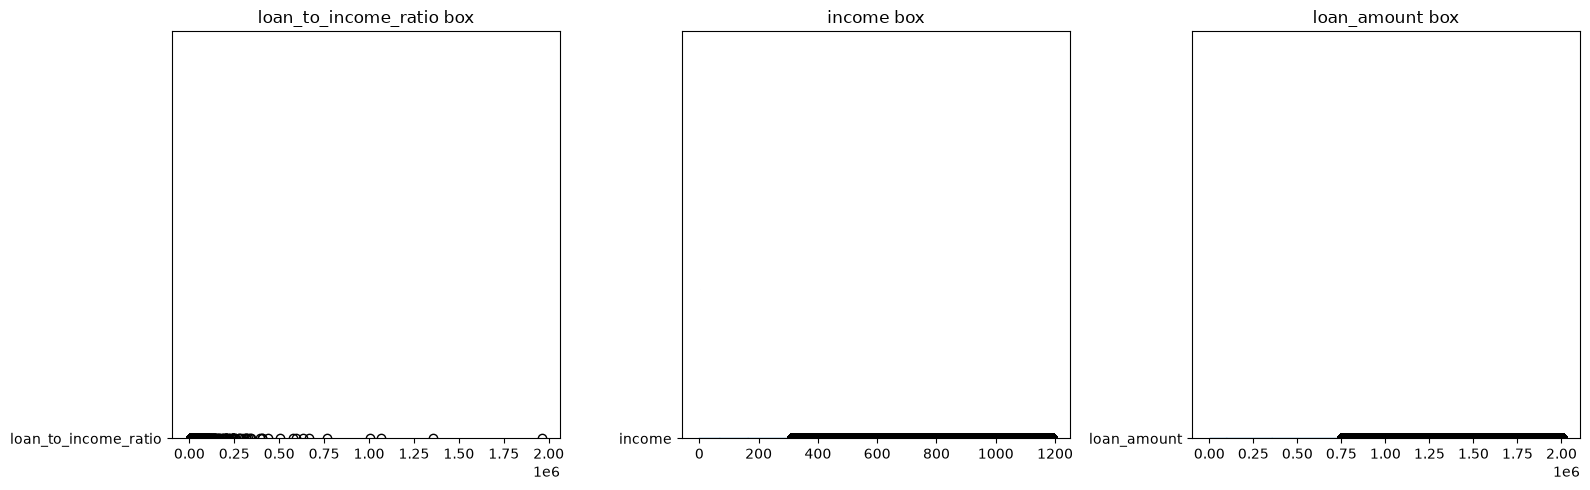

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
s = df_plot['loan_to_income_ratio'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[0].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('loan_to_income_ratio hist [log]')
elif skew > 1:
    axes[0].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('loan_to_income_ratio hist [log1p]')
else:
    axes[0].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('loan_to_income_ratio hist')
s.plot.box(ax=axes[0], vert=False, patch_artist=True)
axes[0].set_title('loan_to_income_ratio box')
s = df_plot['income'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[1].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('income hist [log]')
elif skew > 1:
    axes[1].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('income hist [log1p]')
else:
    axes[1].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('income hist')
s.plot.box(ax=axes[1], vert=False, patch_artist=True)
axes[1].set_title('income box')
s = df_plot['loan_amount'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[2].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('loan_amount hist [log]')
elif skew > 1:
    axes[2].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('loan_amount hist [log1p]')
else:
    axes[2].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('loan_amount hist')
s.plot.box(ax=axes[2], vert=False, patch_artist=True)
axes[2].set_title('loan_amount box')
plt.tight_layout(); plt.show()

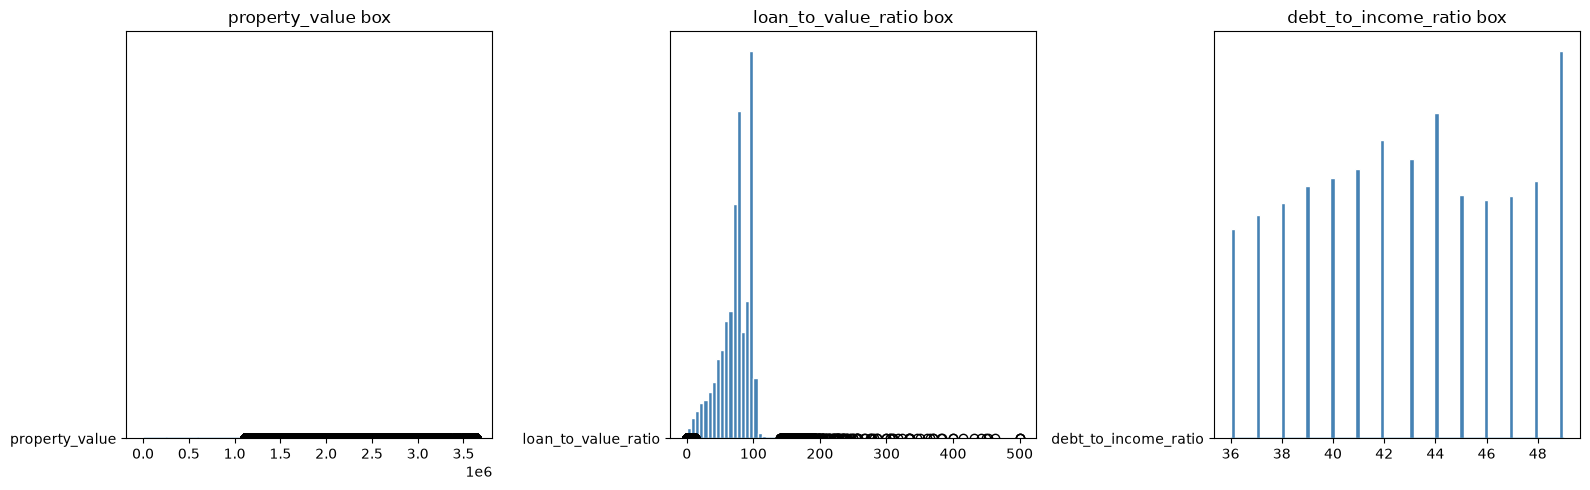

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
s = df_plot['property_value'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[0].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('property_value hist [log]')
elif skew > 1:
    axes[0].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('property_value hist [log1p]')
else:
    axes[0].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('property_value hist')
s.plot.box(ax=axes[0], vert=False, patch_artist=True)
axes[0].set_title('property_value box')
s = df_plot['loan_to_value_ratio'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[1].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('loan_to_value_ratio hist [log]')
elif skew > 1:
    axes[1].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('loan_to_value_ratio hist [log1p]')
else:
    axes[1].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('loan_to_value_ratio hist')
s.plot.box(ax=axes[1], vert=False, patch_artist=True)
axes[1].set_title('loan_to_value_ratio box')
s = df_plot['debt_to_income_ratio'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[2].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('debt_to_income_ratio hist [log]')
elif skew > 1:
    axes[2].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('debt_to_income_ratio hist [log1p]')
else:
    axes[2].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('debt_to_income_ratio hist')
s.plot.box(ax=axes[2], vert=False, patch_artist=True)
axes[2].set_title('debt_to_income_ratio box')
plt.tight_layout(); plt.show()

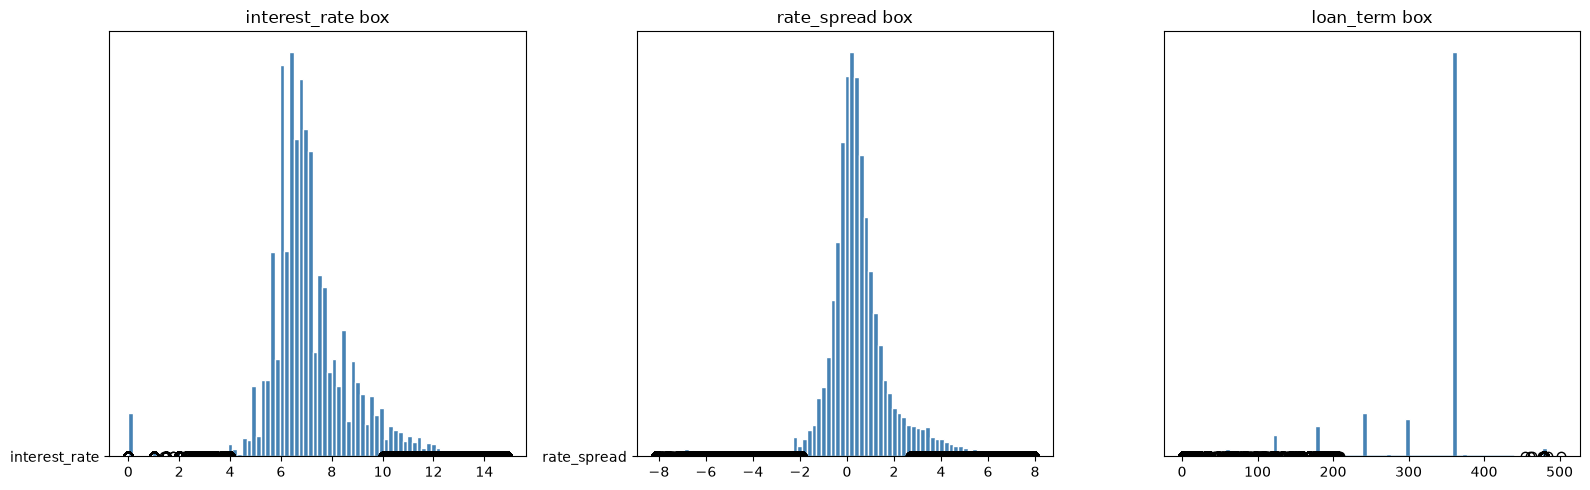

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
s = df_plot['interest_rate'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[0].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('interest_rate hist [log]')
elif skew > 1:
    axes[0].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('interest_rate hist [log1p]')
else:
    axes[0].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('interest_rate hist')
s.plot.box(ax=axes[0], vert=False, patch_artist=True)
axes[0].set_title('interest_rate box')
s = df_plot['rate_spread'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[1].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('rate_spread hist [log]')
elif skew > 1:
    axes[1].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('rate_spread hist [log1p]')
else:
    axes[1].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('rate_spread hist')
s.plot.box(ax=axes[1], vert=False, patch_artist=True)
axes[1].set_title('rate_spread box')
s = df_plot['loan_term'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[2].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('loan_term hist [log]')
elif skew > 1:
    axes[2].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('loan_term hist [log1p]')
else:
    axes[2].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('loan_term hist')
s.plot.box(ax=axes[2], vert=False, patch_artist=True)
axes[2].set_title('loan_term box')
plt.tight_layout(); plt.show()

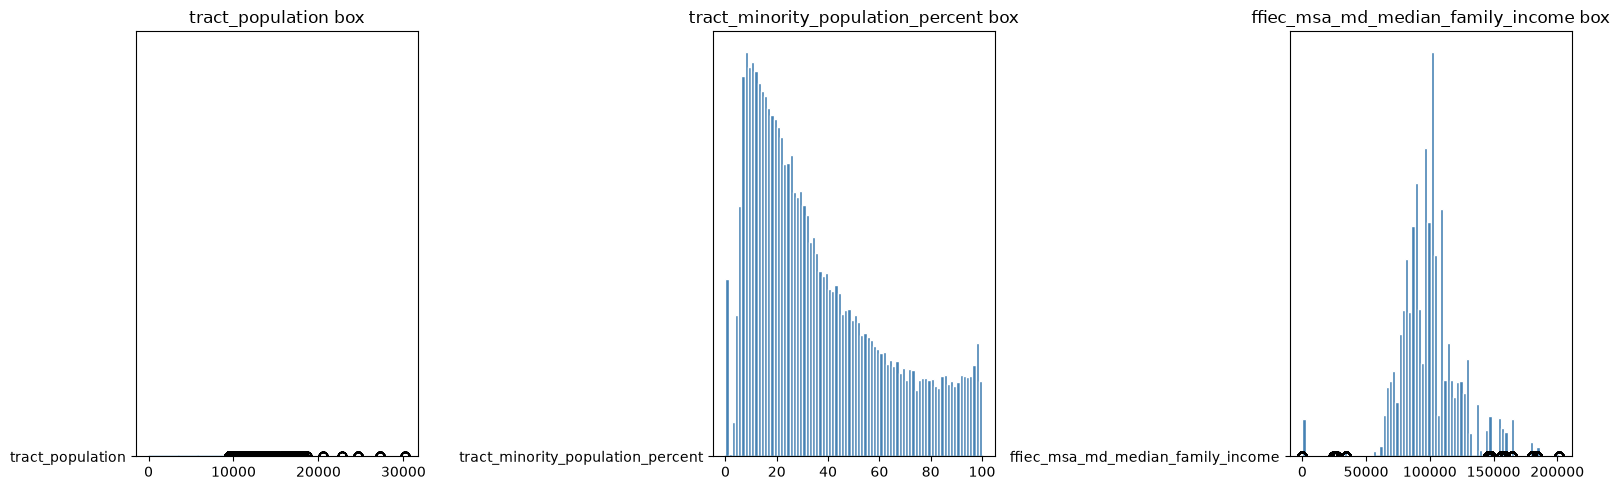

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
s = df_plot['tract_population'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[0].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_population hist [log]')
elif skew > 1:
    axes[0].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_population hist [log1p]')
else:
    axes[0].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_population hist')
s.plot.box(ax=axes[0], vert=False, patch_artist=True)
axes[0].set_title('tract_population box')
s = df_plot['tract_minority_population_percent'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[1].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('tract_minority_population_percent hist [log]')
elif skew > 1:
    axes[1].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('tract_minority_population_percent hist [log1p]')
else:
    axes[1].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('tract_minority_population_percent hist')
s.plot.box(ax=axes[1], vert=False, patch_artist=True)
axes[1].set_title('tract_minority_population_percent box')
s = df_plot['ffiec_msa_md_median_family_income'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[2].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('ffiec_msa_md_median_family_income hist [log]')
elif skew > 1:
    axes[2].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('ffiec_msa_md_median_family_income hist [log1p]')
else:
    axes[2].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('ffiec_msa_md_median_family_income hist')
s.plot.box(ax=axes[2], vert=False, patch_artist=True)
axes[2].set_title('ffiec_msa_md_median_family_income box')
plt.tight_layout(); plt.show()

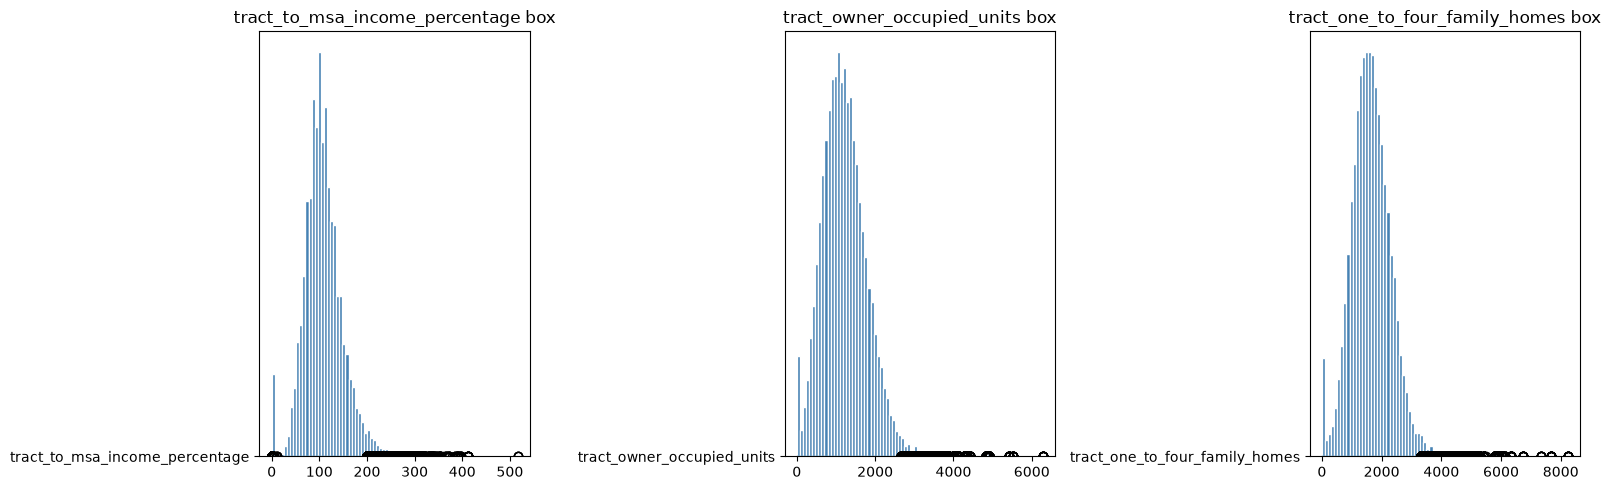

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
s = df_plot['tract_to_msa_income_percentage'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[0].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_to_msa_income_percentage hist [log]')
elif skew > 1:
    axes[0].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_to_msa_income_percentage hist [log1p]')
else:
    axes[0].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_to_msa_income_percentage hist')
s.plot.box(ax=axes[0], vert=False, patch_artist=True)
axes[0].set_title('tract_to_msa_income_percentage box')
s = df_plot['tract_owner_occupied_units'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[1].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('tract_owner_occupied_units hist [log]')
elif skew > 1:
    axes[1].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('tract_owner_occupied_units hist [log1p]')
else:
    axes[1].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[1].set_title('tract_owner_occupied_units hist')
s.plot.box(ax=axes[1], vert=False, patch_artist=True)
axes[1].set_title('tract_owner_occupied_units box')
s = df_plot['tract_one_to_four_family_homes'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[2].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('tract_one_to_four_family_homes hist [log]')
elif skew > 1:
    axes[2].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('tract_one_to_four_family_homes hist [log1p]')
else:
    axes[2].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[2].set_title('tract_one_to_four_family_homes hist')
s.plot.box(ax=axes[2], vert=False, patch_artist=True)
axes[2].set_title('tract_one_to_four_family_homes box')
plt.tight_layout(); plt.show()

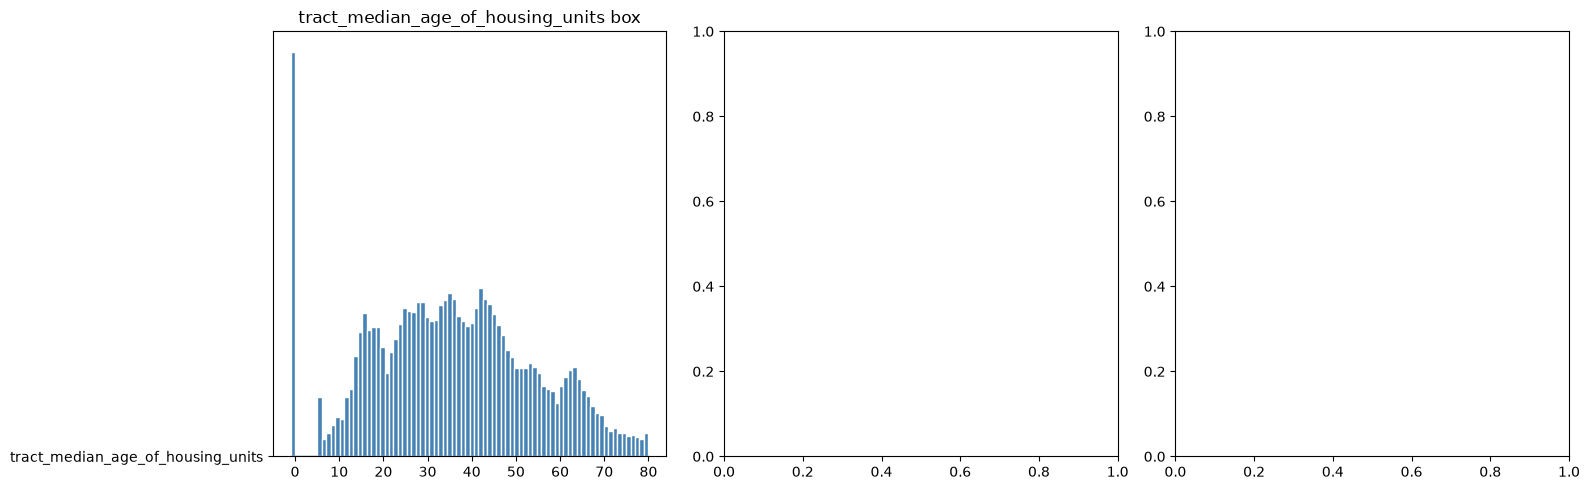

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
s = df_plot['tract_median_age_of_housing_units'].dropna()
skew = s.skew()
if (s > 0).all() and skew > 1:
    axes[0].hist(np.log(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_median_age_of_housing_units hist [log]')
elif skew > 1:
    axes[0].hist(np.log1p(s), bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_median_age_of_housing_units hist [log1p]')
else:
    axes[0].hist(s, bins=80, color='steelblue', edgecolor='white')
    axes[0].set_title('tract_median_age_of_housing_units hist')
s.plot.box(ax=axes[0], vert=False, patch_artist=True)
axes[0].set_title('tract_median_age_of_housing_units box')
plt.tight_layout(); plt.show()

In [8]:
# Consolidated summary statistics (full file)
rows = []
for col in CONTINUOUS:
    s = df[col].dropna()
    rows.append(dict(feature=col, mean=s.mean(), median=s.median(), std=s.std(),
                     skew=s.skew(), kurtosis=s.kurtosis(), min=s.min(), max=s.max()))
tbl = pd.DataFrame(rows).set_index('feature')
print(tbl.round(3).to_string())
tbl.to_csv(FIG / 'continuous_summary_stats.csv')
print('wrote', FIG / 'continuous_summary_stats.csv')


                                            mean         median            std        skew      kurtosis       min          max
feature                                                                                                                        
loan_to_income_ratio                 2387.562012    1994.219971    7832.125977  111.393997  19201.689453     4.198  2004999.875
income                                141.296005     104.000000     140.910004    3.961000     21.815001     0.000     1191.000
loan_amount                        270897.500000  205000.000000  268739.812500    2.894000     12.739000  5000.000  2004999.875
property_value                     503937.062500  385000.000000  450977.375000    3.522000     17.365000  5000.000  3635000.000
loan_to_value_ratio                    73.203003      78.766998      23.583000   -0.328000      5.583000     0.001      500.000
debt_to_income_ratio                   42.862999      43.000000       3.999000   -0.045000     -1.145000

## **A.2 — Univariate: Categorical / Discrete Features**

Bar chart of value counts / proportions for each categorical field. Pie charts are reserved for genuinely low-cardinality fields (<=5-6 categories) where proportions are the story: `loan_purpose`, `occupancy_type`, `preapproval`, `lien_status`, `derived_dwelling_category`.


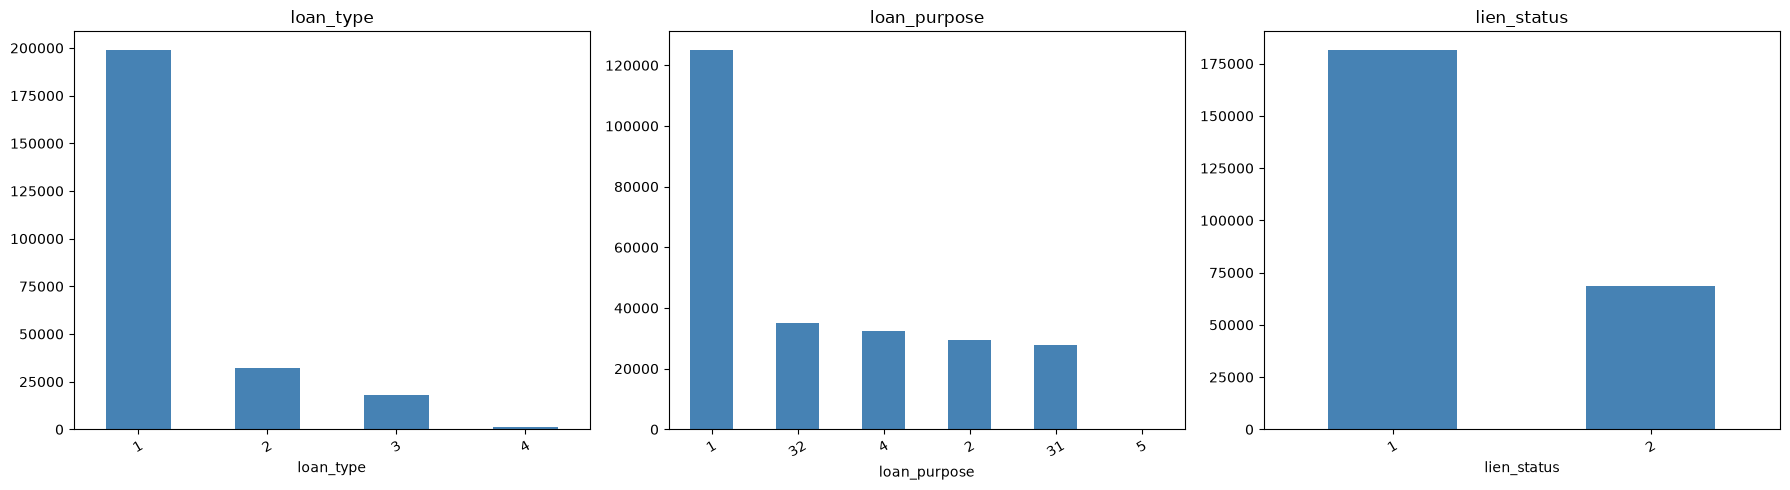

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(6*3, 5))
vc = df_plot['loan_type'].value_counts()
vc.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('loan_type')
axes[0].tick_params(axis='x', rotation=30)
vc = df_plot['loan_purpose'].value_counts()
vc.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('loan_purpose')
axes[1].tick_params(axis='x', rotation=30)
vc = df_plot['lien_status'].value_counts()
vc.plot.bar(ax=axes[2], color='steelblue')
axes[2].set_title('lien_status')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

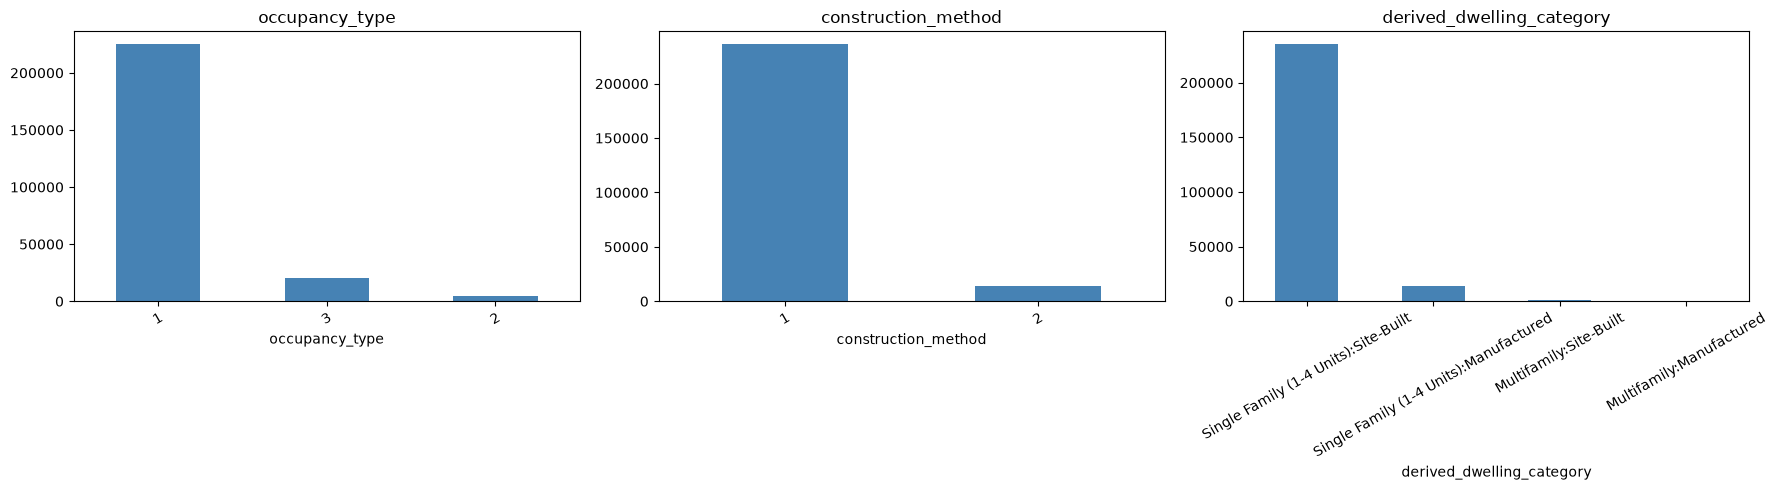

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(6*3, 5))
vc = df_plot['occupancy_type'].value_counts()
vc.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('occupancy_type')
axes[0].tick_params(axis='x', rotation=30)
vc = df_plot['construction_method'].value_counts()
vc.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('construction_method')
axes[1].tick_params(axis='x', rotation=30)
vc = df_plot['derived_dwelling_category'].value_counts()
vc.plot.bar(ax=axes[2], color='steelblue')
axes[2].set_title('derived_dwelling_category')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

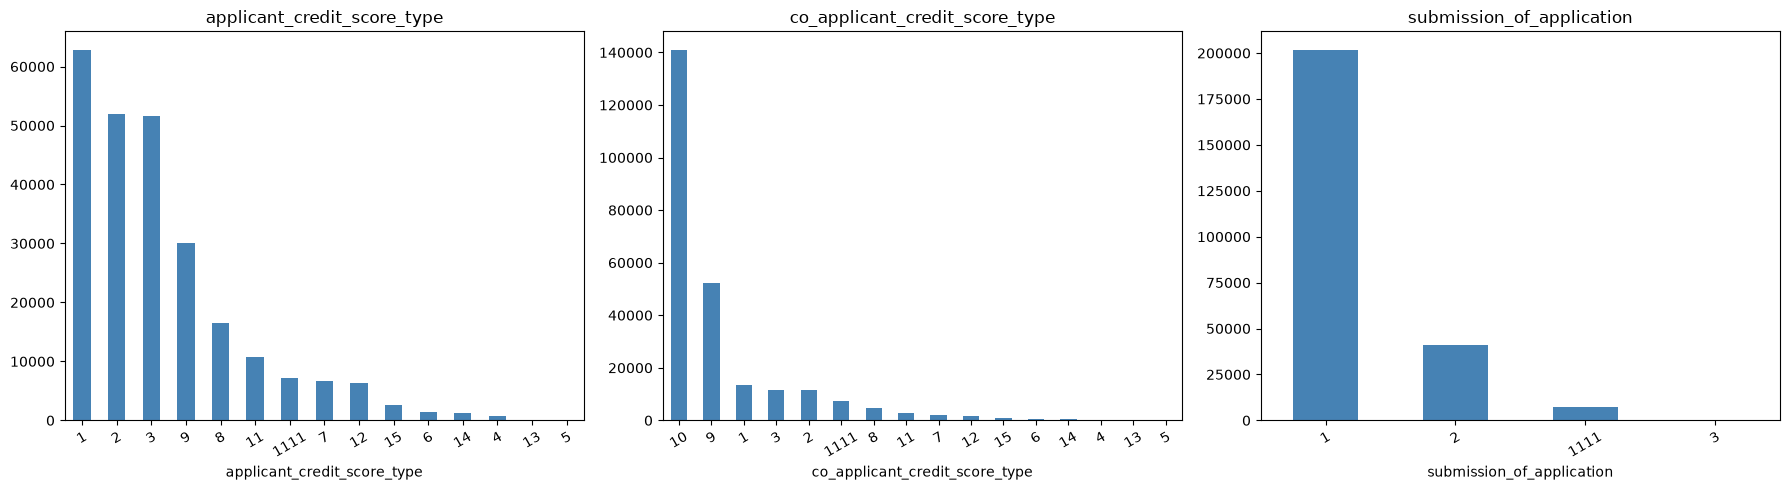

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(6*3, 5))
vc = df_plot['applicant_credit_score_type'].value_counts()
vc.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('applicant_credit_score_type')
axes[0].tick_params(axis='x', rotation=30)
vc = df_plot['co_applicant_credit_score_type'].value_counts()
vc.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('co_applicant_credit_score_type')
axes[1].tick_params(axis='x', rotation=30)
vc = df_plot['submission_of_application'].value_counts()
vc.plot.bar(ax=axes[2], color='steelblue')
axes[2].set_title('submission_of_application')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

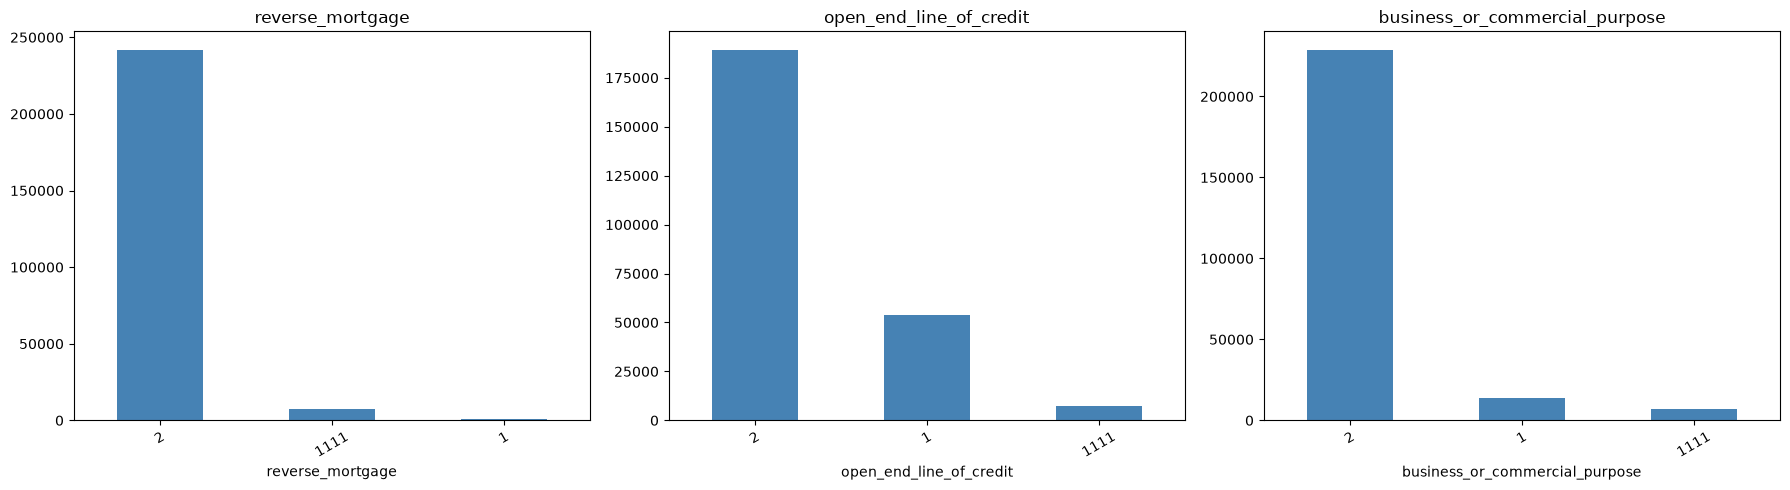

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(6*3, 5))
vc = df_plot['reverse_mortgage'].value_counts()
vc.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('reverse_mortgage')
axes[0].tick_params(axis='x', rotation=30)
vc = df_plot['open_end_line_of_credit'].value_counts()
vc.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('open_end_line_of_credit')
axes[1].tick_params(axis='x', rotation=30)
vc = df_plot['business_or_commercial_purpose'].value_counts()
vc.plot.bar(ax=axes[2], color='steelblue')
axes[2].set_title('business_or_commercial_purpose')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

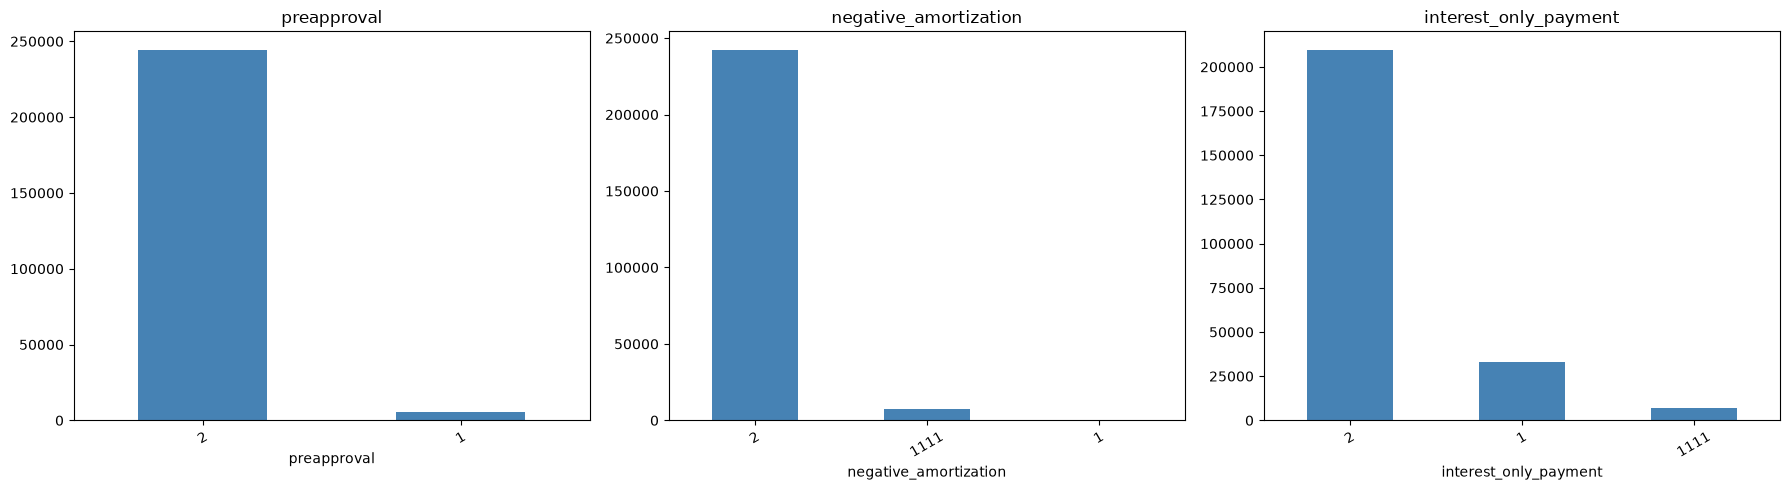

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(6*3, 5))
vc = df_plot['preapproval'].value_counts()
vc.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('preapproval')
axes[0].tick_params(axis='x', rotation=30)
vc = df_plot['negative_amortization'].value_counts()
vc.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('negative_amortization')
axes[1].tick_params(axis='x', rotation=30)
vc = df_plot['interest_only_payment'].value_counts()
vc.plot.bar(ax=axes[2], color='steelblue')
axes[2].set_title('interest_only_payment')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

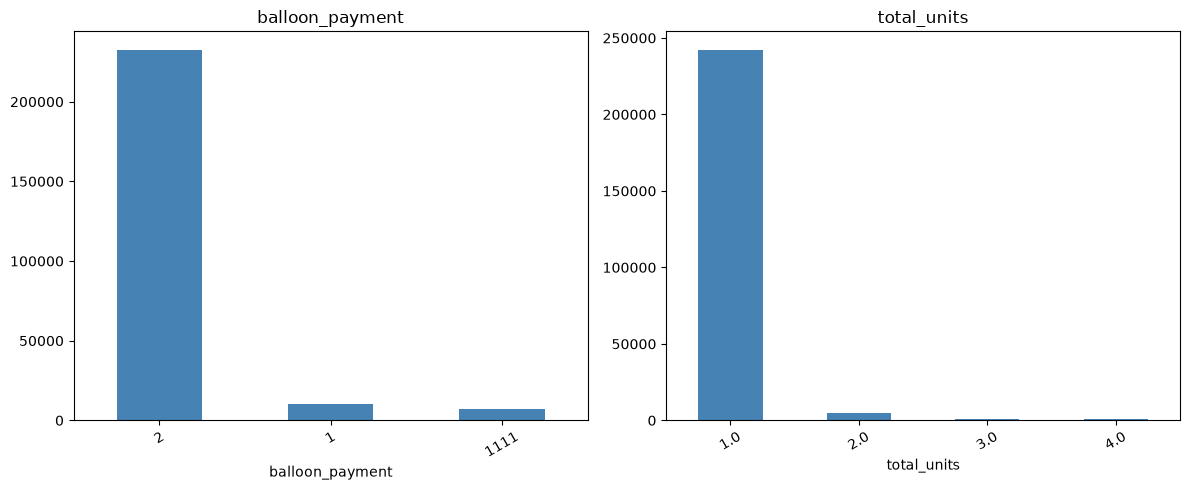

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 5))
vc = df_plot['balloon_payment'].value_counts()
vc.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('balloon_payment')
axes[0].tick_params(axis='x', rotation=30)
vc = df_plot['total_units'].value_counts()
vc.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('total_units')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

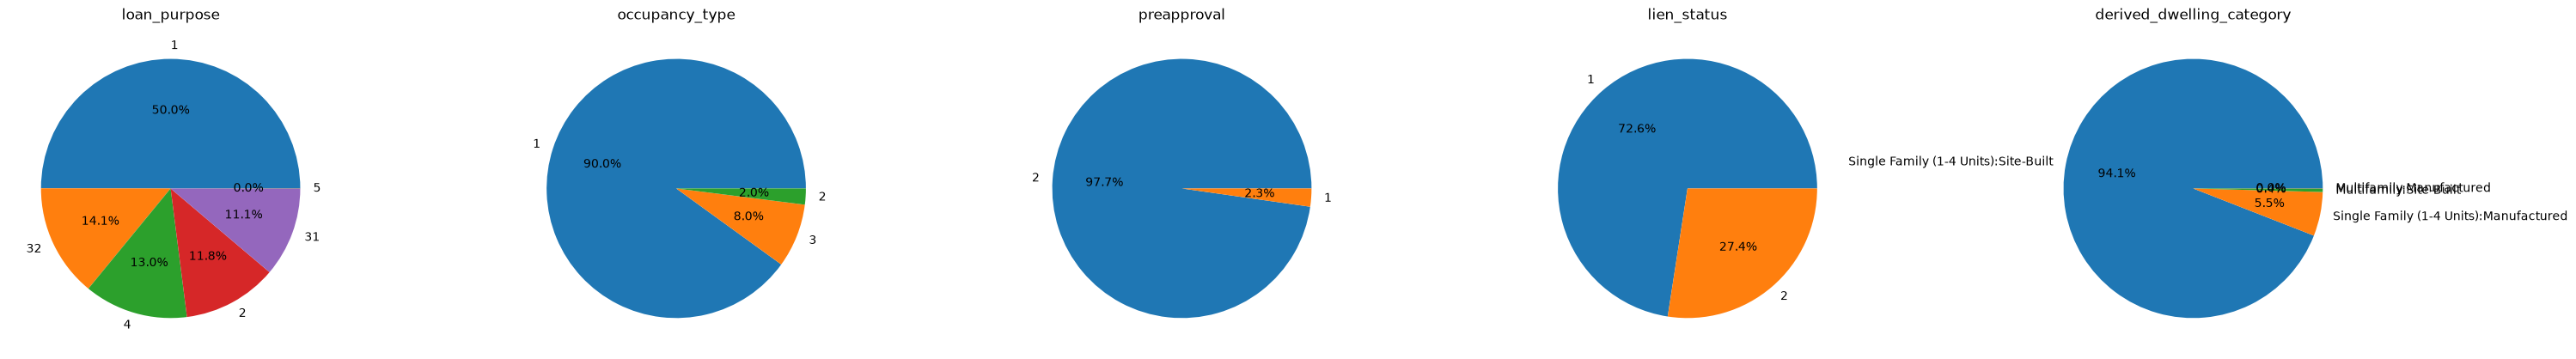

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(6*5, 5))
df_plot['loan_purpose'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('loan_purpose')
axes[0].set_ylabel('')
df_plot['occupancy_type'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('occupancy_type')
axes[1].set_ylabel('')
df_plot['preapproval'].value_counts().plot.pie(ax=axes[2], autopct='%1.1f%%')
axes[2].set_title('preapproval')
axes[2].set_ylabel('')
df_plot['lien_status'].value_counts().plot.pie(ax=axes[3], autopct='%1.1f%%')
axes[3].set_title('lien_status')
axes[3].set_ylabel('')
df_plot['derived_dwelling_category'].value_counts().plot.pie(ax=axes[4], autopct='%1.1f%%')
axes[4].set_title('derived_dwelling_category')
axes[4].set_ylabel('')
plt.tight_layout(); plt.show()

## **A.3 — Target and Demographic Composition**

Re-confirm the ~74.6% approval rate and Day 1's demographic composition on this deduped file (Day 1's 74.63% was pre-dedup; 11,036 duplicate rows were removed).


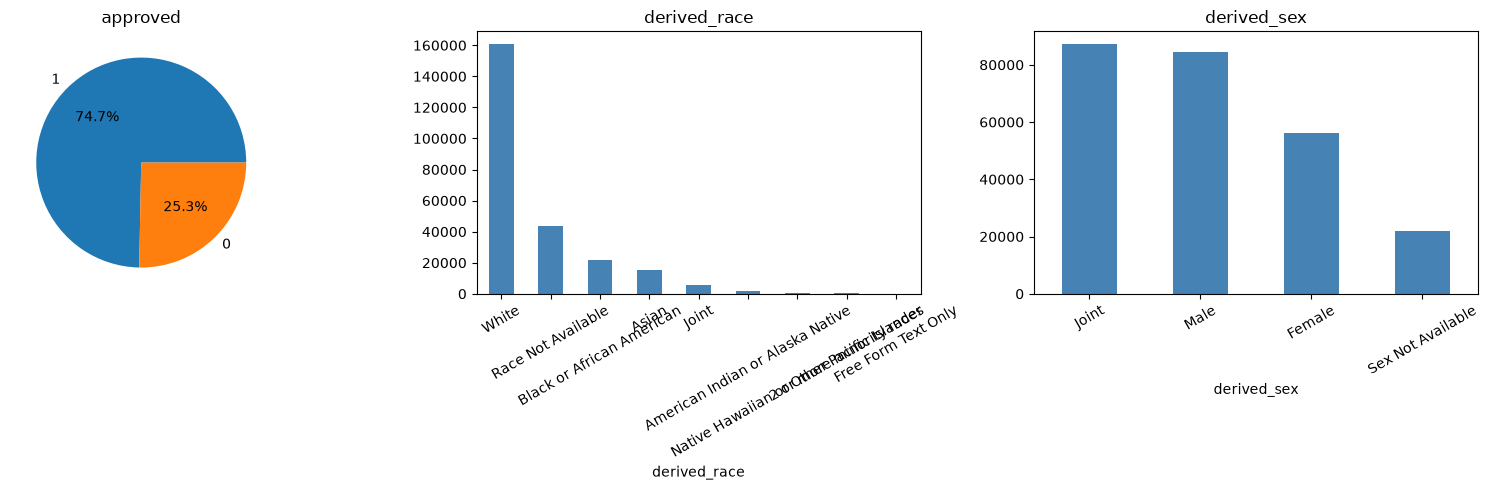

approved share (full): 0.7465178992525332
derived_race n: 9
derived_ethnicity n: 5
derived_sex n: 4


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df_plot['approved'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('approved'); axes[0].set_ylabel('')
df_plot['derived_race'].value_counts().plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('derived_race'); axes[1].tick_params(axis='x', rotation=30)
df_plot['derived_sex'].value_counts().plot.bar(ax=axes[2], color='steelblue')
axes[2].set_title('derived_sex'); axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print('approved share (full):', df['approved'].mean())
print('derived_race n:', df['derived_race'].nunique())
print('derived_ethnicity n:', df['derived_ethnicity'].nunique())
print('derived_sex n:', df['derived_sex'].nunique())


## **A.4 — Missingness**

Missingness bar chart (% missing per column, sorted descending) on this file's actual pre-imputation numbers — this supersedes Day 2/3's missingness table with corrected, dedup-adjusted denominators. A missingness co-occurrence view (boolean correlation heatmap) shows whether missing `debt_to_income_ratio` tends to co-occur with missing `loan_to_value_ratio` (context for why `debt_to_income_ratio_missing` became Day 8's #2 SHAP feature).


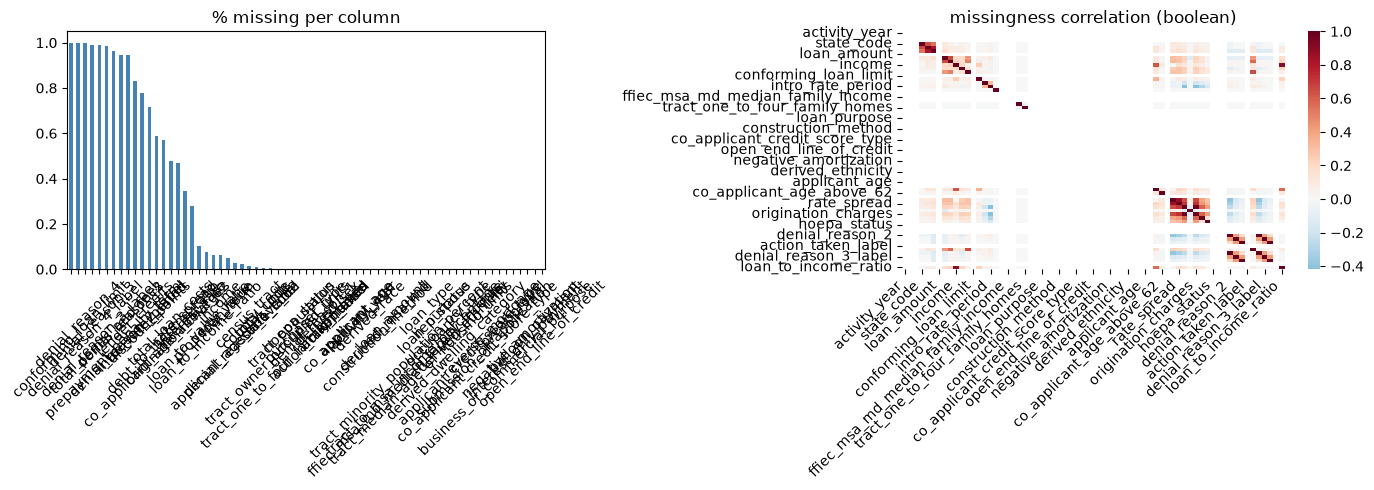

debt_to_income_ratio & loan_to_value_ratio corr: 0.181


In [17]:
missing = df.isna().mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('% missing per column'); axes[0].tick_params(axis='x', rotation=45)
bool_corr = df.isna().astype(int).corr()
sns.heatmap(bool_corr, cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_title('missingness correlation (boolean)')
plt.tight_layout(); plt.show()
print('debt_to_income_ratio & loan_to_value_ratio corr:', round(bool_corr.loc['debt_to_income_ratio','loan_to_value_ratio'], 3))


## **A.5 — Bivariate: Feature vs. Target**

Box plots of `income`, `loan_amount`, `debt_to_income_ratio`, `loan_to_value_ratio` grouped by `approved` (visual precursor to what the model later learned). Bar chart of approval rate by key categorical features. Approval rate by `derived_race` and `derived_sex` recomputed on this deduped file (consistency check against Day 2's raw numbers).


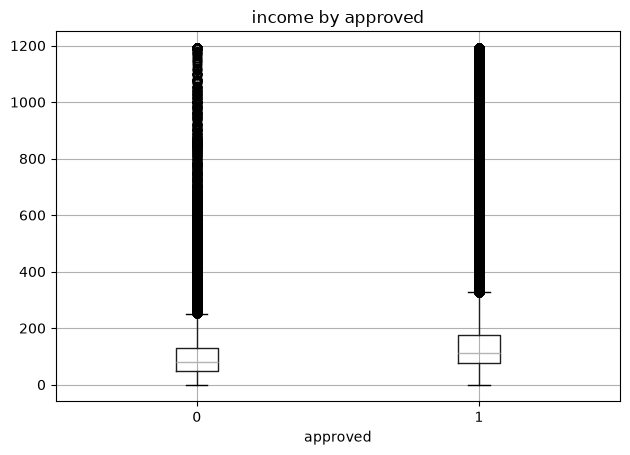

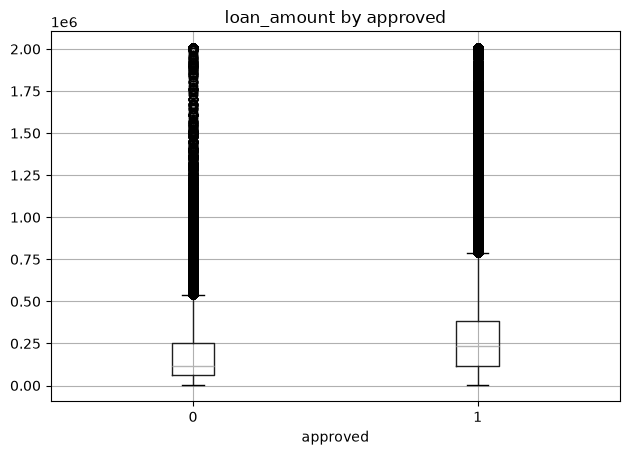

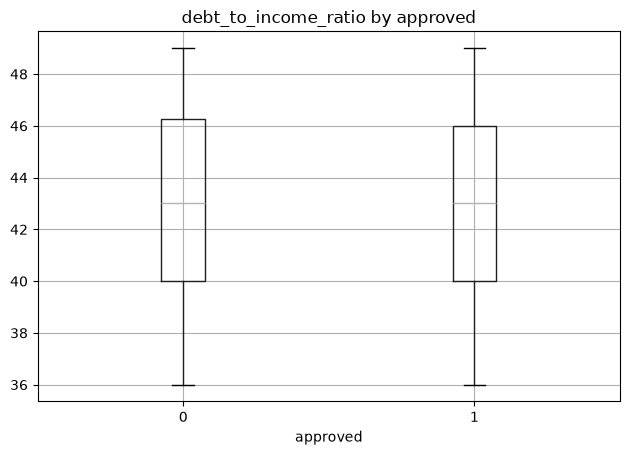

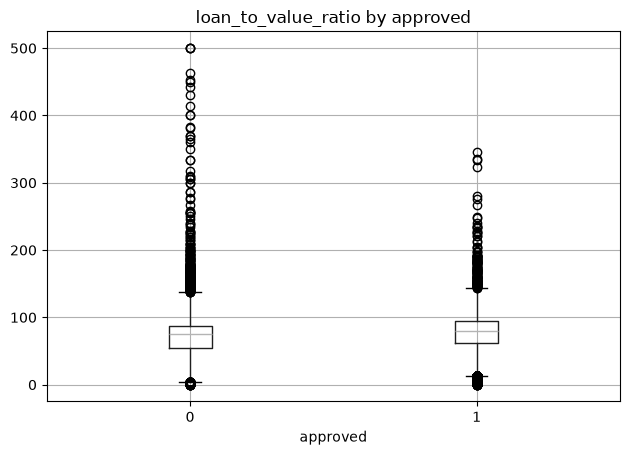

In [18]:
for col in ['income', 'loan_amount', 'debt_to_income_ratio', 'loan_to_value_ratio']:
    df_plot.boxplot(column=col, by='approved', ax=plt.gca())
    plt.title(f'{col} by approved'); plt.suptitle(''); plt.tight_layout(); plt.show()


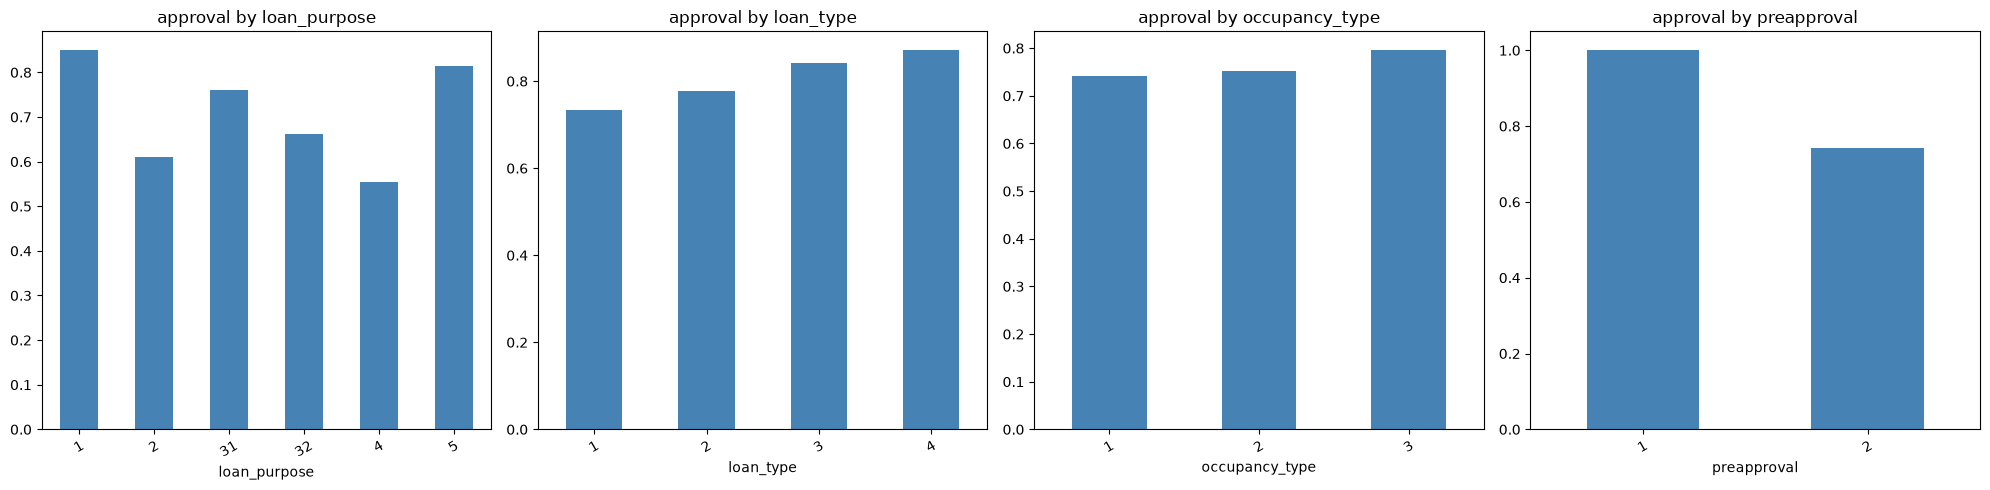

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for j, col in enumerate(['loan_purpose', 'loan_type', 'occupancy_type', 'preapproval']):
    df_plot.groupby(col)['approved'].mean().plot.bar(ax=axes[j], color='steelblue')
    axes[j].set_title(f'approval by {col}'); axes[j].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


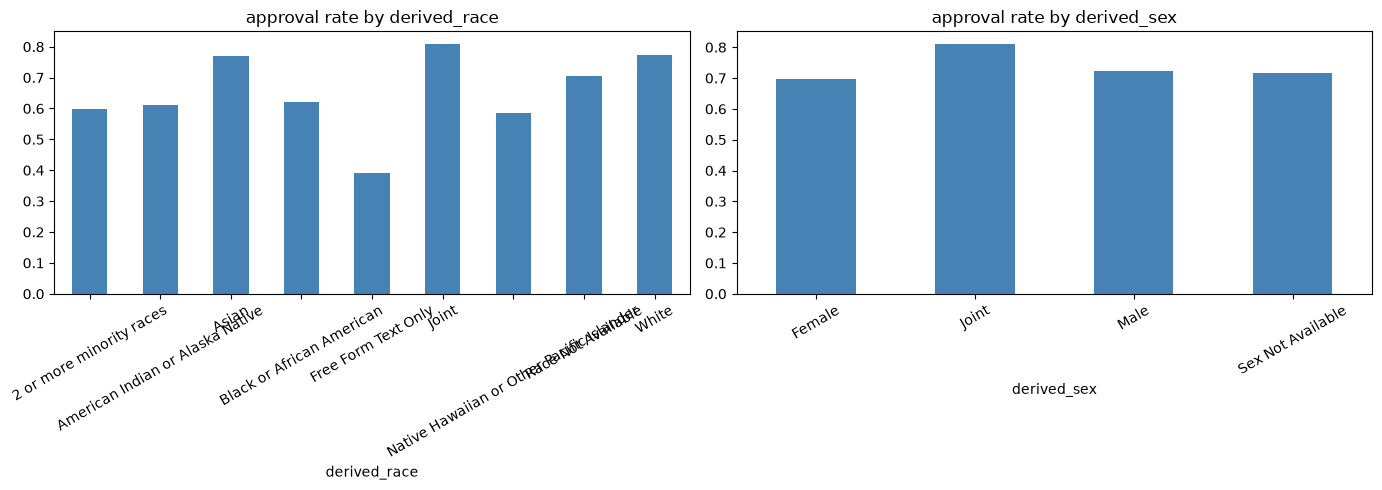

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_plot.groupby('derived_race')['approved'].mean().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('approval rate by derived_race'); axes[0].tick_params(axis='x', rotation=30)
df_plot.groupby('derived_sex')['approved'].mean().plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('approval rate by derived_sex'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


## **A.6 — Bivariate: Feature vs. Feature**

Scatterplots of `income` vs. `loan_amount`, `property_value` vs. `loan_amount`, `loan_to_value_ratio` vs. `debt_to_income_ratio` (colored by `approved` where it adds a visual story). A dedicated scatter of `tract_minority_population_percent` vs. `tract_to_msa_income_percentage` — the race-proxy pair that sets up Day 9 Part B.


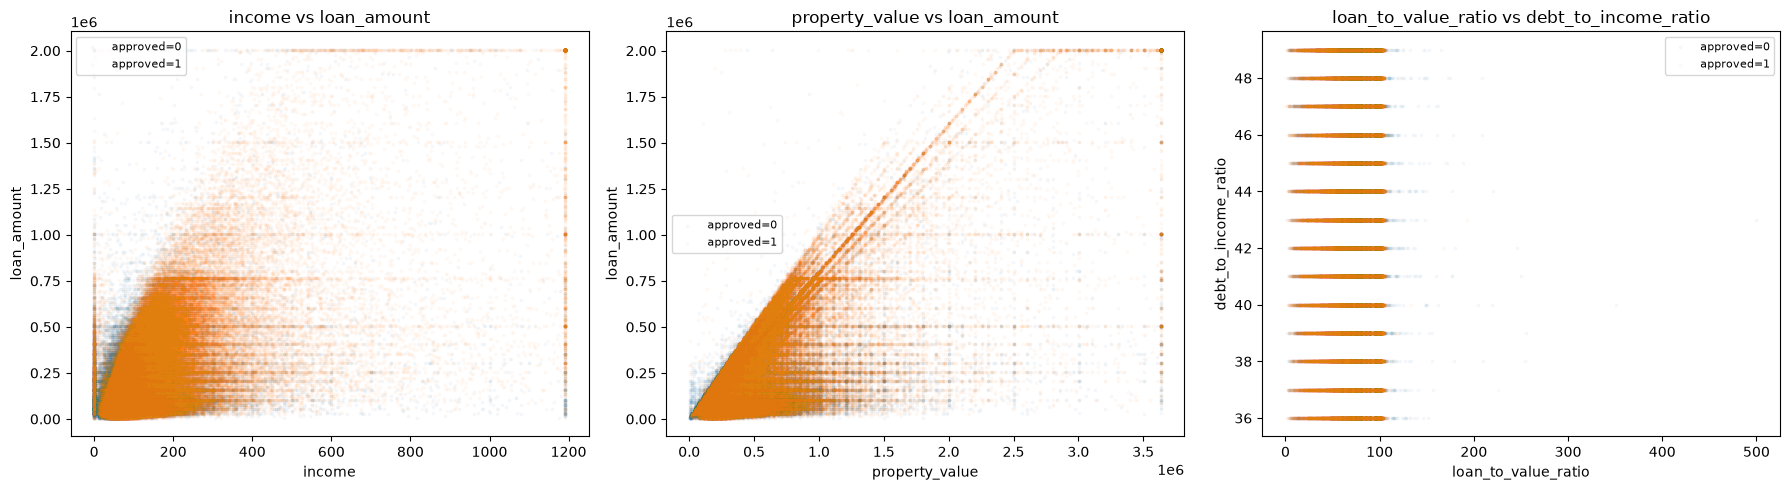

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('income','loan_amount'), ('property_value','loan_amount'), ('loan_to_value_ratio','debt_to_income_ratio')]
for j, (x,y) in enumerate(pairs):
    for av in [0,1]:
        sub = df_plot[df_plot['approved']==av]
        axes[j].scatter(sub[x], sub[y], alpha=0.03, label=f'approved={av}', s=3)
    axes[j].set_xlabel(x); axes[j].set_ylabel(y); axes[j].legend(fontsize=8)
    axes[j].set_title(f'{x} vs {y}')
plt.tight_layout(); plt.show()


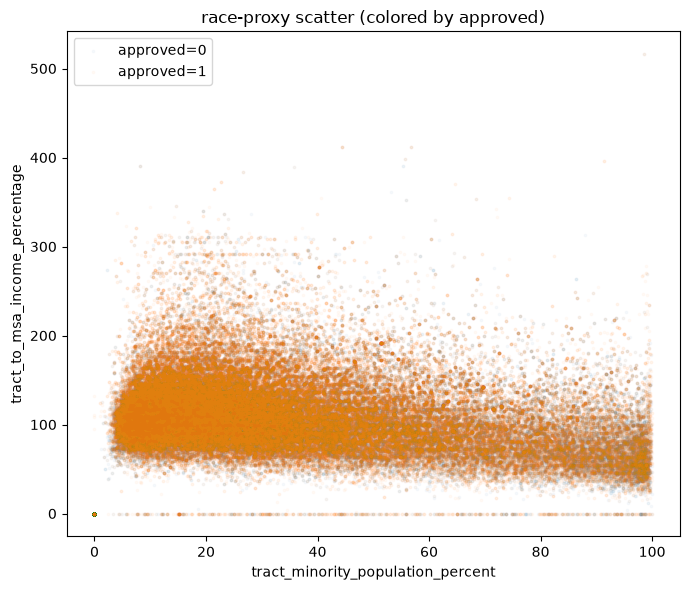

In [22]:
fig, ax = plt.subplots(figsize=(7,6))
sub = df_plot[['tract_minority_population_percent','tract_to_msa_income_percentage','approved']].dropna()
for av in [0,1]:
    s = sub[sub['approved']==av]
    ax.scatter(s['tract_minority_population_percent'], s['tract_to_msa_income_percentage'],
               alpha=0.03, label=f'approved={av}', s=3)
ax.set_xlabel('tract_minority_population_percent'); ax.set_ylabel('tract_to_msa_income_percentage')
ax.legend(); ax.set_title('race-proxy scatter (colored by approved)')
plt.tight_layout(); plt.show()


## **A.7 — Correlation / Multivariate**

Pearson correlation heatmap across all continuous features (cross-check against Day 5's VIF findings — max 6.44, no severe multicollinearity). A second, focused heatmap on the `tract_*` geography cluster plus `ffiec_msa_md_median_family_income`.


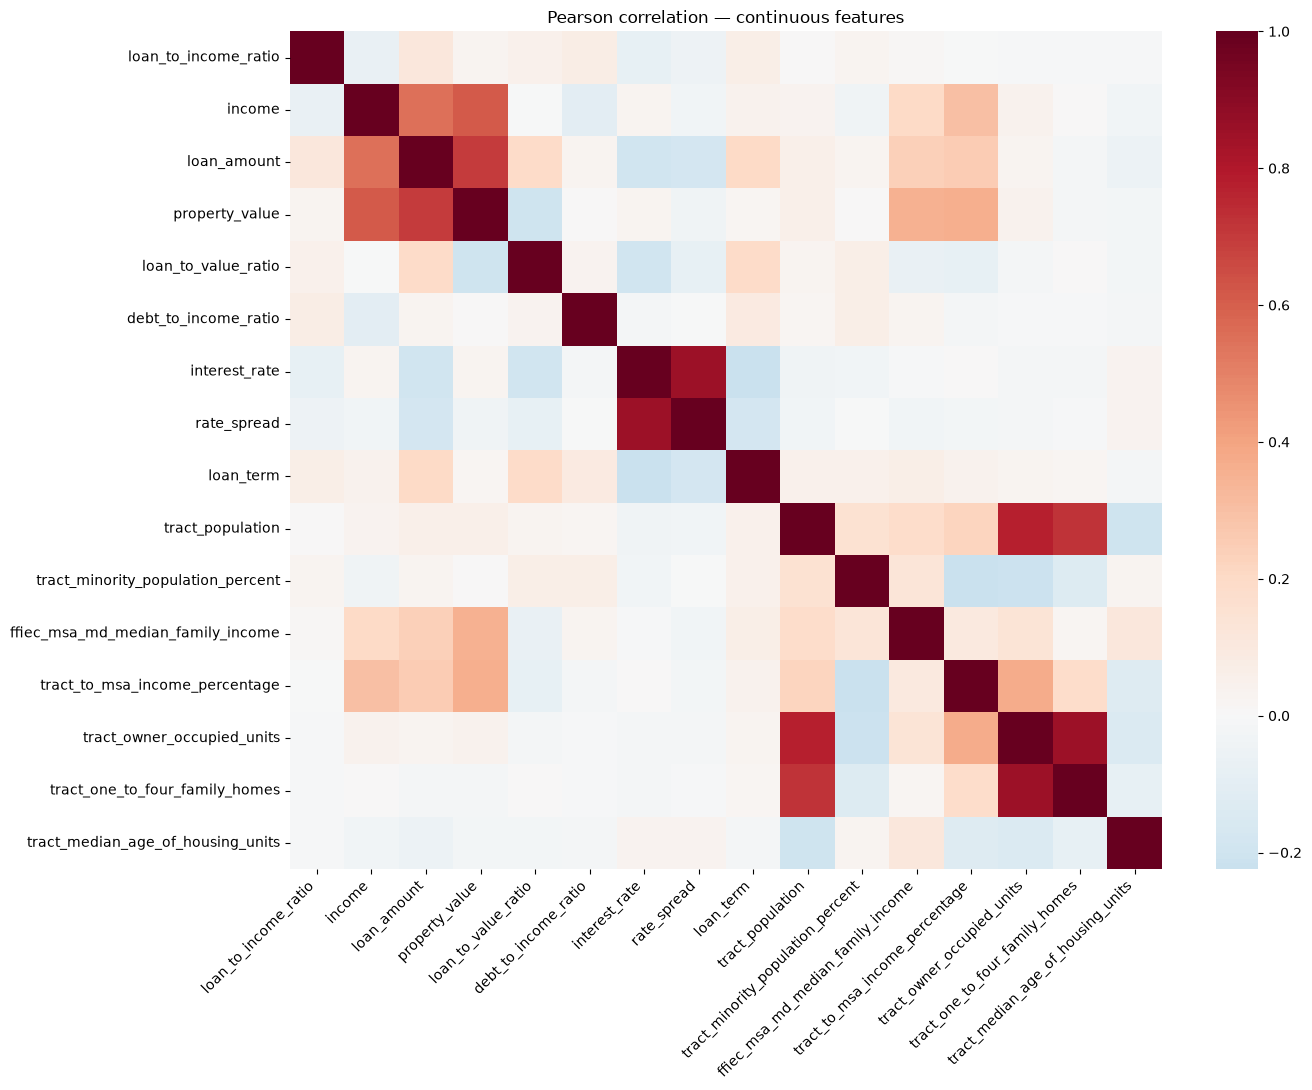

In [23]:
cont = CONTINUOUS
corr = df_plot[cont].corr()
fig, ax = plt.subplots(figsize=(14,11))
sns.heatmap(corr, cmap='RdBu_r', center=0, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Pearson correlation — continuous features'); plt.tight_layout(); plt.show()


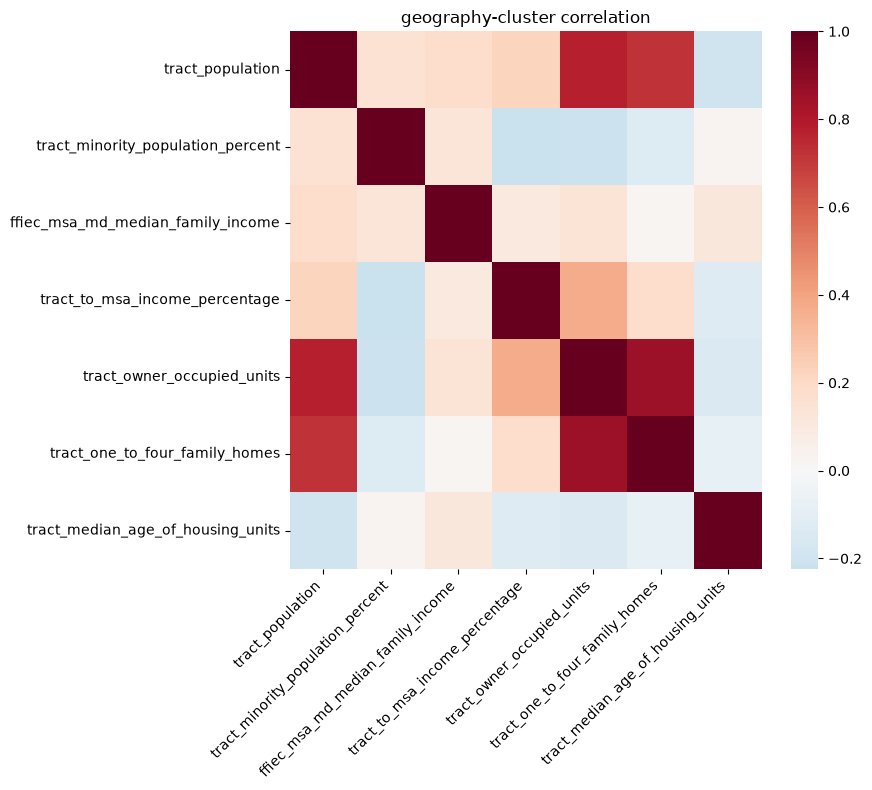

In [24]:
geo = [c for c in CONTINUOUS if c.startswith('tract_') or c == 'ffiec_msa_md_median_family_income']
corr_g = df_plot[geo].corr()
fig, ax = plt.subplots(figsize=(9,8))
sns.heatmap(corr_g, cmap='RdBu_r', center=0, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('geography-cluster correlation'); plt.tight_layout(); plt.show()


## **A.8 — Demographic-Specific Distributions**

Box plots of `income`, `loan_amount`, `debt_to_income_ratio`, `loan_to_value_ratio` by `derived_race` and by `derived_sex` (extends Day 2's median-only comparison into a full distributional view). The most directly relevant plot for what comes next: `tract_minority_population_percent` by `derived_race` — the visual, model-free counterpart to Day 8's SHAP finding that this feature's contribution differs by race group.


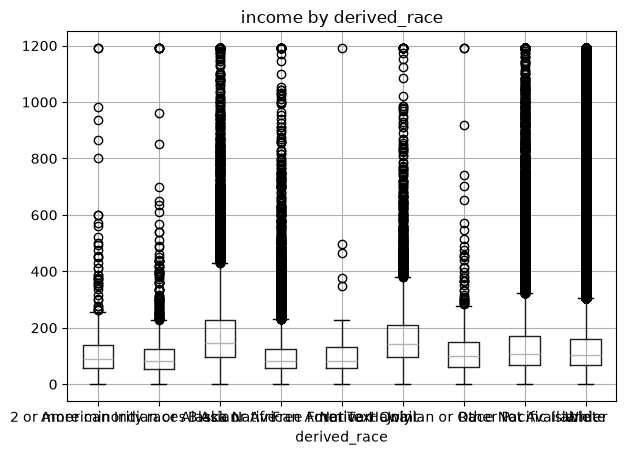

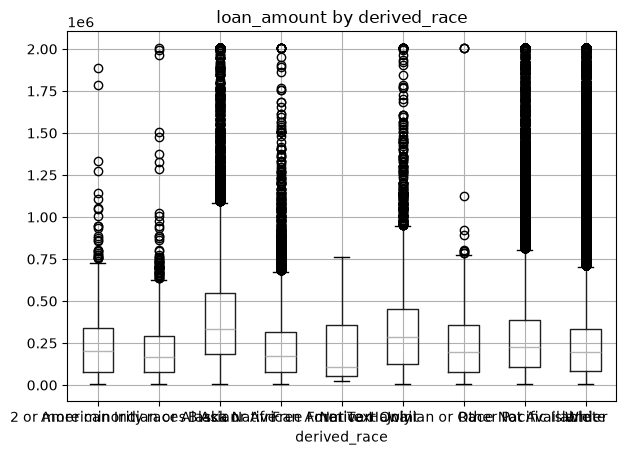

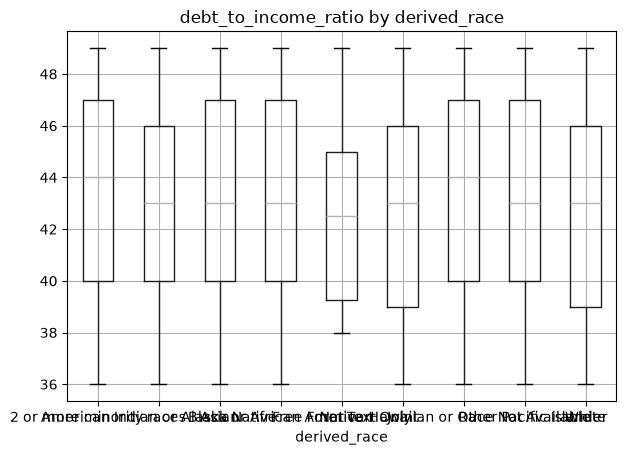

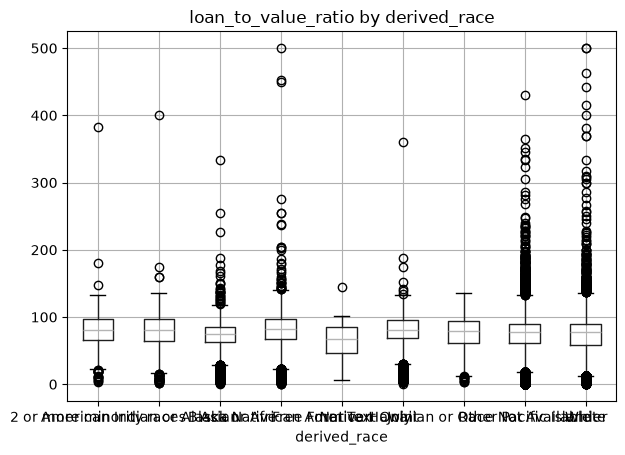

In [25]:
for col in ['income', 'loan_amount', 'debt_to_income_ratio', 'loan_to_value_ratio']:
    df_plot.boxplot(column=col, by='derived_race')
    plt.title(f'{col} by derived_race'); plt.suptitle(''); plt.tight_layout(); plt.show()


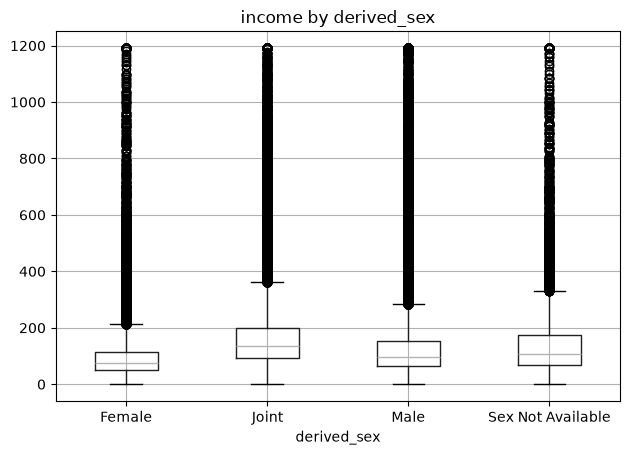

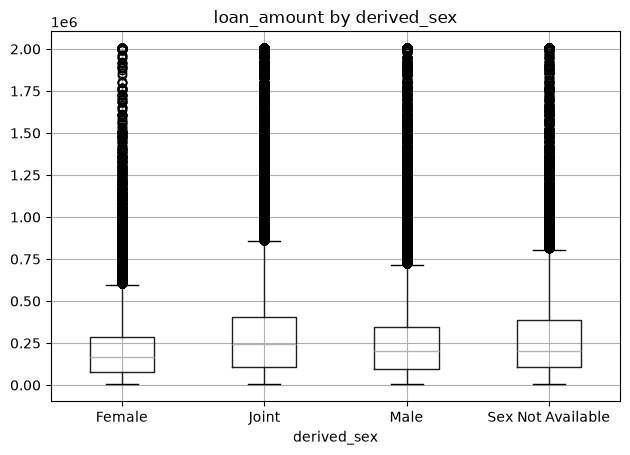

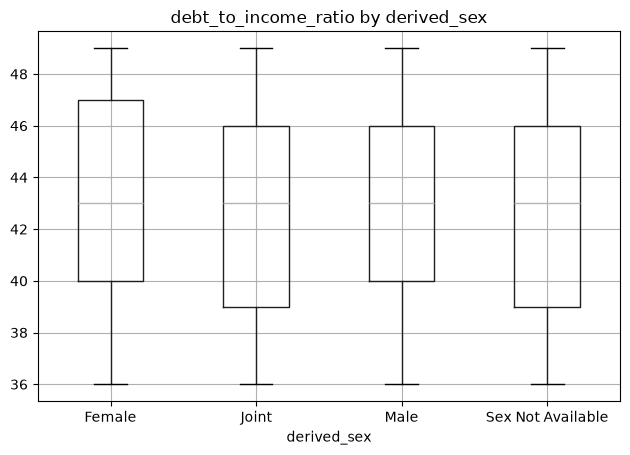

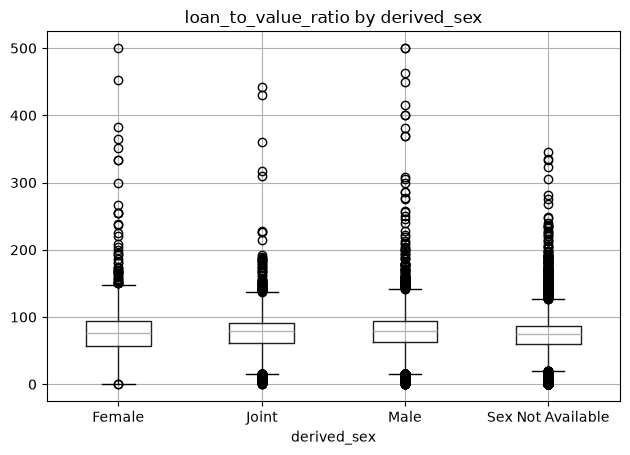

In [26]:
for col in ['income', 'loan_amount', 'debt_to_income_ratio', 'loan_to_value_ratio']:
    df_plot.boxplot(column=col, by='derived_sex')
    plt.title(f'{col} by derived_sex'); plt.suptitle(''); plt.tight_layout(); plt.show()


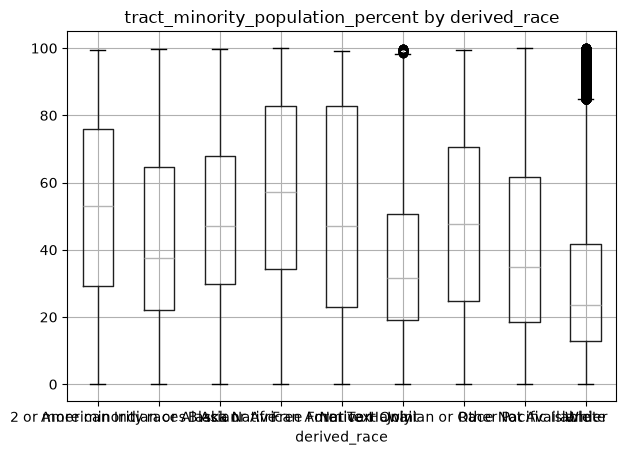

In [27]:
df_plot.boxplot(column='tract_minority_population_percent', by='derived_race')
plt.title('tract_minority_population_percent by derived_race'); plt.suptitle(''); plt.tight_layout(); plt.show()


## **A.9 — Optional Geography (lower priority)**

Top-10 states by volume and state-level approval-rate comparison — easy descriptive context, skipped if time is tight.


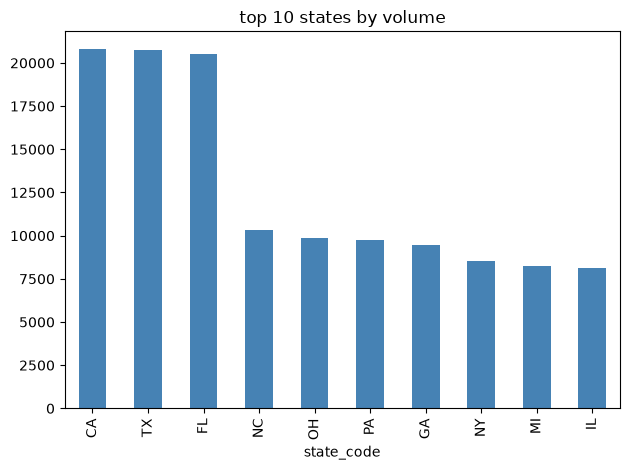

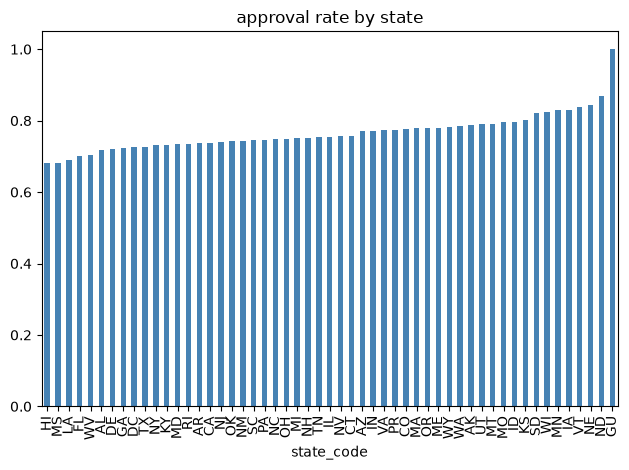

top-10 states: ['CA', 'TX', 'FL', 'NC', 'OH', 'PA', 'GA', 'NY', 'MI', 'IL']


In [28]:
top10 = df_plot['state_code'].value_counts().head(10)
top10.plot.bar(color='steelblue'); plt.title('top 10 states by volume'); plt.tight_layout(); plt.show()
state_approval = df_plot.groupby('state_code')['approved'].mean().sort_values()
state_approval.plot.bar(color='steelblue'); plt.title('approval rate by state'); plt.tight_layout(); plt.show()
print('top-10 states:', list(top10.index))


## **Part A — Deliverable & close-out notes**

- `hmda_eda.ipynb` is a standalone, exploratory notebook: every plot rendered inline, **none** saved to a `figures/` directory.
- No modeling changes result from this notebook; it closes out the README's Day 3 requirement.
- Key checks performed: right-skew handling, Day 2 outlier-cleaning confirmation, dedup-adjusted class balance and demographic composition, genuine pre-imputation missingness patterns, missingness co-occurrence, and the `tract_minority_population_percent`-by-race distribution that grounds Day 9 Part B's proxy discussion.
